<a href="https://colab.research.google.com/github/Alle84fr/Kim_matemat/blob/04_censo/censo_2022_Alessandra_2401151.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ao criar drive, deixe no colab Notebooks, que era o que já estava

Modifique o código para que nomeie os estados com menos de um milhão de habitantes. Construir o boxplot e identifique se há outliers. Identifique máximo, mínimo. Calcule o primeiro quartil e o terceiro quartil.


.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


csv (Comma Separated Values = biblioteca que permite ler e escrever arquivos csv

pnadas para análise de dados

In [ ]:
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

para relembrar, df = dataframe = tabela de dados

sep=";" = colunas sepradas por ;

latin1 = para caracteres especiais

.plot(df["eixo x"],df['eixo y'])

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Censo_2022_a .csv',sep=",",encoding="latin1", header=1)


In [ ]:
print(df)

    Unnamed: 0 Unidade da FederaÃ§Ã£o Sigla     Total
0            0                    RondÃ´nia   1581196
1            1                         Acre    830018
2            2                     Amazonas   3941613
3            3                      Roraima    636707
4            4                        ParÃ¡   8120131
5            5                       AmapÃ¡    733759
6            6                    Tocantins   1511460
7            7                    MaranhÃ£o   6776699
8            8                       PiauÃ­   3271199
9            9                       CearÃ¡   8794957
10          10          Rio Grande do Norte   3302729
11          11                     ParaÃ­ba   3974687
12          12                   Pernambuco   9058931
13          13                      Alagoas   3127683
14          14                      Sergipe   2210004
15          15                        Bahia  14141626
16          16                 Minas Gerais  20539989
17          17              

In [ ]:
populacao = df["Total"].sum()

densidade = populacao/8510000

cont = 0
for p in df ["Total"]:
  if p < 1000000:
    cont += 1


In [ ]:
print(f"""População do Brasil: {populacao:.2f}
      Sua densidade é de : {densidade:.2f}
      Possui {cont:.2f} de países com menos de um milhão de habitantes""")

População do Brasil: 203080756.00
      Sua densidade é de : 23.86
      Possui 3.00 de países com menos de um milhão de habitantes


In [ ]:
quant = len(df["Total"])

media = np.mean(df["Total"])

mediana = np.median(df['Total'])

varianca = np.var(df["Total"])

desvio_padrao = np.std(df["Total"])

minimo = np.min(df["Total"])

maximo = np.max(df["Total"])

amplitude = (maximo) - (minimo)

Q1 = np.percentile(df["Total"], 25)

Q3 = np.percentile(df["Total"], 75)

Q2_amplitude = (Q3) - (Q1)

coeficinete_var = desvio_padrao / media

outLier_base = Q1 - 1.5

outLier_topo = Q3 + 1.5

mu = np.mean((df["Total"] - media) **4)

curtose = mu / ((desvio_padrao**4) - 3)

desvio < = 50% da mediana= n°s estão mais próximos
desvio >= mediana = numeros mais espalhados
desvio >= 200% da mediana = extremamente espalhado

In [ ]:
mediana_porcento = (desvio_padrao/media)*100

In [ ]:
print(f"""Foram analisados {quant} Estados do Brasil.

Considerando a média, posso dizer que a quantidade de pessoas distribuídas igualmente por Estado seria de {media:.2f} ocupantes.

O Estado com menor valor tem {minimo:.2f} habitantes, enquanto o Estado com maior valor fica com {maximo:.2f} de 'povo', tendo uma diferença de
{amplitude:.2f} entre eles.

Metade destes Estados possui mais de {media:.2f} cidadãos.

A variação fica em torno de {varianca:.2f}, tendo mais de {mediana_porcento:.2f}% de variação em relação ao valor referente à metade da
população, fator que mostra que há uma certa distribuição de gente pelo território.

Por fim, os dados mostram que 25% dos Estados possuem até {Q1:.2f} moradores e 75% dos Estados possuem {Q3:.2f} moradores; porém, há
locais, por volta de {curtose:.2f}, que apresentam valores muito fora do padrão.
""")



Foram analisados 27 Estados do Brasil.

Considerando a média, posso dizer que a quantidade de pessoas distribuídas igualmente por Estado seria de 7521509.48 ocupantes.

O Estado com menor valor tem 636707.00 habitantes, enquanto o Estado com maior valor fica com 44411238.00 de 'povo', tendo uma diferença de
43774531.00 entre eles.

Metade destes Estados possui mais de 7521509.48 cidadãos.

A variação fica em torno de 76688099824846.77, tendo mais de 116.43% de variação em relação ao valor referente à metade da
população, fator que mostra que há uma certa distribuição de gente pelo território.

Por fim, os dados mostram que 25% dos Estados possuem até 2787197.00 moradores e 75% dos Estados possuem 8926944.00 moradores; porém, há
locais, por volta de 11.97, que apresentam valores muito fora do padrão.



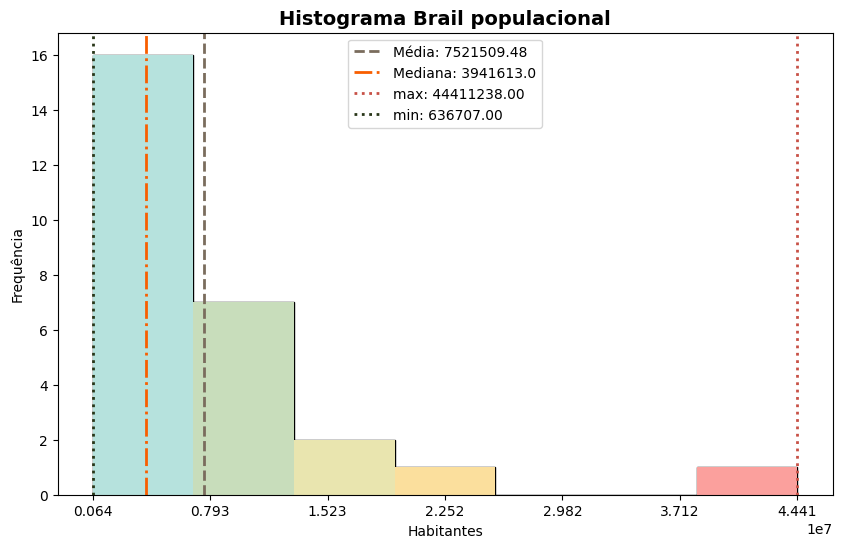

In [ ]:
from matplotlib.lines import lineStyles
import seaborn as sns

plt.figure(figsize=(10,6))

bins = 7

sns.histplot(df["Total"], bins=7)

#linspace, quantos n°s quero entre início e fim
plt.xticks(np.linspace(df["Total"].min(), df["Total"].max(), bins))

counts, edges, bars = plt.hist(df['Total'], bins=bins)

colors = ["#b6e2dd","#c8ddbb","#e9e5af","#fbdf9d","#fbc99d","#fbb39d","#fba09d"]

for bar, color in zip(bars, colors):
    bar.set_facecolor(color)
#______________________________________


plt.axvline(media, color="#7a6c5d", linestyle="--", linewidth=2, label=f"Média: {media:.2f}")

plt.axvline(mediana, color="#f85e00", linestyle="-.", linewidth=2, label=f"Mediana: {mediana}")

plt.axvline(maximo, color="#c75146", linestyle=":", linewidth=2, label=f"max: {maximo:.2f}")

plt.axvline(minimo, color="#283618", linestyle=":", linewidth=2, label=f"min: {minimo:.2f}")

plt.title("Histograma Brail populacional", fontsize=14, fontweight="bold")

plt.xlabel("Habitantes")

plt.ylabel("Frequência")

plt.legend()




plt.show()

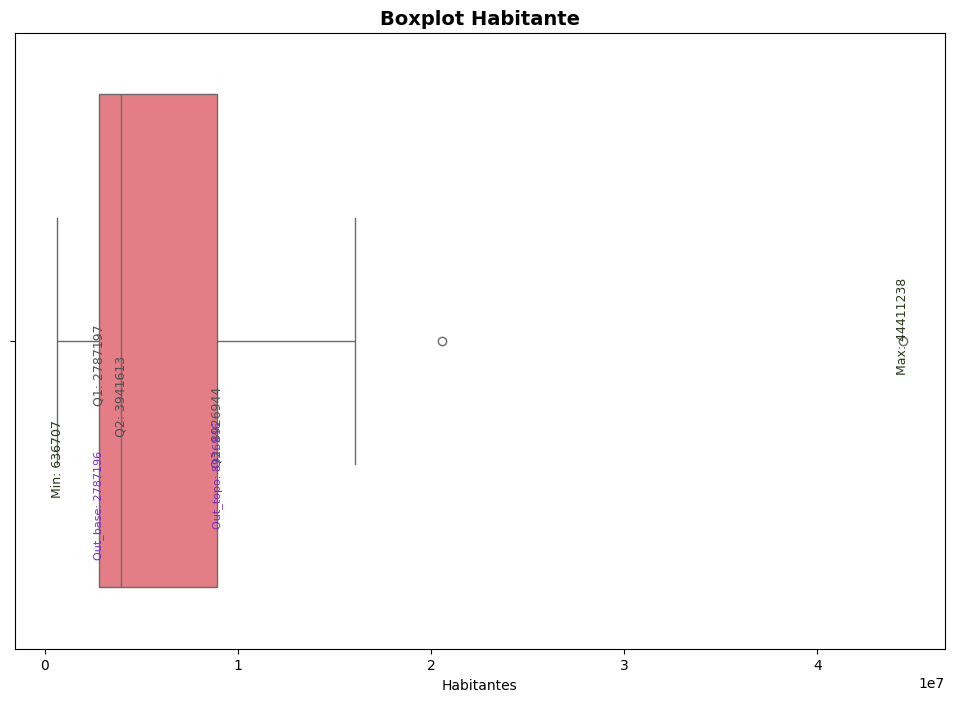

In [ ]:
plt.figure(figsize=(12,8))

sns.boxplot(x=df['Total'], color="#f56c77")

plt.title("Boxplot Habitante", fontsize=14, fontweight="bold")

plt.text(Q1, 0.10, f"Q1: {Q1:.0f}", color="#495057", fontsize=9, rotation=90, ha="center")

plt.text(mediana, 0.15, f"Q2: {mediana:.0f}", color="#495057", fontsize=9, rotation=90, ha="center")

plt.text(Q3, 0.20, f"Q3: {Q3:.0f}", color="#495057", fontsize=9, rotation=90, ha="center")

plt.text(outLier_base, 0.35, f"Out_base: {outLier_base:.0f}", color="#7b2cbf", fontsize=8, rotation=90, ha="center")

plt.text(outLier_topo, 0.30, f"Out_topo: {outLier_topo:.0f}", color="#7b2cbf", fontsize=8, rotation=90, ha="center")

plt.text(minimo, 0.25, f"Min: {minimo}", color="#283618", fontsize=9, rotation=90, ha="center")

plt.text(maximo, 0.05, f"Max: {maximo}", color="#283618", fontsize=9, rotation=90, ha="center")

plt.xlabel("Habitantes")

plt.show()